# Witness Complex Analysis of Population Coverage — Census Tract Level
## Research — TDA MATH 497

**Landmarks** = farthest-point sample from census tract centroids (`svi_tracts.geojson`)  
**Witnesses** = all 2,493 census tract centroids  

Finer granularity than the neighborhood-level analysis: each census tract centroid represents a small population unit. Fire stations are overlaid for spatial context.

## Step 1 — Install Dependencies

In [1]:
# Run once; restart kernel afterwards if installing for the first time
# %pip install gudhi geopandas pyproj matplotlib networkx

## Step 2 — Imports & Configuration

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import geopandas as gpd
import gudhi
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import networkx as nx

# ── Paths ──
STATIONS_PATH   = "../../data/all_stations.geojson"
LA_COUNTY_PATH  = "../../data/la_county.geojson"
SVI_TRACTS_PATH = "../../data/svi_tracts.geojson"   # 2,493 census tracts + population

# ── Coordinate systems ──
CRS_WGS84 = "EPSG:4326"
CRS_UTM   = "EPSG:32611"   # UTM Zone 11N — standard for LA region

# ── Witness complex ──
N_LANDMARKS   = 150         # farthest-point subset of tract centroids
WITNESS_MAX_M = 60_000      # metres; 60 km covers LA County extent
LIMIT_DIM     = 2           # 1=edges only, 2=H0+H1, 3=H0+H1+H2

# ── Persistence diagram ──
H1_SIG_THRESHOLD_M = 5_000  # 5 km — highlight significant H1 voids


## Step 3 — Load & Project Data

In [3]:
# ── Load fire stations ──
stations_wgs = gpd.read_file(STATIONS_PATH).set_crs(CRS_WGS84, allow_override=True)
print(f"Stations loaded : {len(stations_wgs)}")
print(f"  LAFD    : {(stations_wgs['department'] == 'LAFD').sum()}")
print(f"  LACoFD  : {(stations_wgs['department'] == 'LACoFD').sum()}")

# ── Load SVI census tracts ──
svi_tracts = gpd.read_file(SVI_TRACTS_PATH).set_crs(CRS_WGS84, allow_override=True)
print(f"\nCensus tracts loaded : {len(svi_tracts)}")
print(f"Total population     : {svi_tracts['e_totpop'].sum():,.0f}")
print(f"Pop range            : {svi_tracts['e_totpop'].min():,.0f} – {svi_tracts['e_totpop'].max():,.0f}")

# ── Load LA County boundary (for clipping and plotting) ──
county_wgs = gpd.read_file(LA_COUNTY_PATH).set_crs(CRS_WGS84, allow_override=True)

# ── Project to UTM Zone 11N ──
stations_proj = stations_wgs.to_crs(CRS_UTM)
svi_proj      = svi_tracts.to_crs(CRS_UTM)
county_proj   = county_wgs.to_crs(CRS_UTM)

# ── Clip stations to county boundary ──
county_boundary = unary_union(county_proj.geometry)
within_mask     = stations_proj.geometry.within(county_boundary)
stations_proj   = stations_proj[within_mask].copy().reset_index(drop=True)
print(f"\nStations within county : {len(stations_proj)}")

# ── Point clouds ──
svi_proj = svi_proj.copy()
svi_proj["centroid"] = svi_proj.geometry.centroid

witnesses_m = np.column_stack([svi_proj["centroid"].x,
                                svi_proj["centroid"].y])   # (2493, 2)
population  = svi_proj["e_totpop"].values.astype(float)

station_coords_m = np.column_stack([stations_proj.geometry.x,
                                     stations_proj.geometry.y])

print(f"Witness points (tracts)    : {witnesses_m.shape[0]}")
print(f"Station overlay points     : {station_coords_m.shape[0]}")


Stations loaded : 412
  LAFD    : 106
  LACoFD  : 172

Census tracts loaded : 2493
Total population     : 10,032,020
Pop range            : 0 – 12,957

Stations within county : 408
Witness points (tracts)    : 2493
Station overlay points     : 408


## Step 4 — Farthest-Point Landmark Selection

**Landmarks = census tract centroids** (farthest-point subsample from all 2,493).  
With 2,493 tracts as landmarks the complex would be enormous; farthest-point sampling picks `N_LANDMARKS` that spread maximally across the county, preserving the large-scale topology while keeping computation fast.

To see **H2 features** (enclosed 3-D voids), set `LIMIT_DIM = 3` in the config cell.


In [4]:
landmarks_m = np.array(gudhi.choose_n_farthest_points(
    points        = witnesses_m,   # 2,493 tract centroids
    nb_points     = min(N_LANDMARKS, len(witnesses_m)),
    starting_point = 0
))

print(f"Landmarks selected : {len(landmarks_m)} tract centroids "
      f"(farthest-point from {len(witnesses_m)} total)")
ext = landmarks_m.max(0) - landmarks_m.min(0)
print(f"Landmark extent    : {ext[0]/1000:.1f} km (E–W)  ×  {ext[1]/1000:.1f} km (N–S)")


Landmarks selected : 150 tract centroids (farthest-point from 2493 total)
Landmark extent    : 105.5 km (E–W)  ×  179.4 km (N–S)


## Step 5 — Build Witness Complex

### Theory
The **witness complex** $W(L, X, \varepsilon)$ is built from:
- **Landmarks** $L$ — farthest-point sample of census tract centroids (sparse, evenly spread)
- **Witnesses** $X$ — all 2,493 census tract centroids

A simplex $[l_0, \ldots, l_k]$ is admitted at filtration value $\varepsilon$ if there exists a witness $w \in X$ such that
$$\max_i\, d(w,\, l_i) \leq \varepsilon + d(w,\, L_{k+1})$$
where $d(w, L_{k+1})$ is $w$'s distance to its $(k+1)$-th nearest landmark.

Because witnesses are fine-grained census tracts, the filtration picks up coverage gaps at the population level more precisely than the 272-neighborhood version.


In [5]:
print(f"Building Witness complex: {len(landmarks_m)} landmarks, "
      f"{len(witnesses_m)} witnesses, max_ε={WITNESS_MAX_M/1000:.0f} km, dim≤{LIMIT_DIM} ...")

witness_complex = gudhi.EuclideanWitnessComplex(
    witnesses = witnesses_m,
    landmarks = landmarks_m
)

st_witness = witness_complex.create_simplex_tree(
    max_alpha_square = WITNESS_MAX_M ** 2,
    limit_dimension  = LIMIT_DIM
)

print(f"  Total simplices : {st_witness.num_simplices():,}")
print(f"  Vertices        : {st_witness.num_vertices():,}")

# ── Compute persistence ──
st_witness.compute_persistence(homology_coeff_field=2, min_persistence=0)
print("Persistence computed.")

# ── Extract H0 / H1 / H2 pairs ──
H0, H0_inf = [], []
H1, H1_inf = [], []
H2, H2_inf = [], []
for dim, (b, d) in st_witness.persistence():
    if dim == 0:
        (H0_inf if np.isinf(d) else H0).append((b, d))
    elif dim == 1:
        (H1_inf if np.isinf(d) else H1).append((b, d))
    elif dim == 2:
        (H2_inf if np.isinf(d) else H2).append((b, d))

print(f"H0 finite  : {len(H0):>4}   H0 infinite : {len(H0_inf)}")
print(f"H1 finite  : {len(H1):>4}   H1 infinite : {len(H1_inf)}")
if LIMIT_DIM >= 3:
    print(f"H2 finite  : {len(H2):>4}   H2 infinite : {len(H2_inf)}")


Building Witness complex: 150 landmarks, 2493 witnesses, max_ε=60 km, dim≤2 ...
  Total simplices : 543,765
  Vertices        : 150
Persistence computed.
H0 finite  :    3   H0 infinite : 1
H1 finite  :   30   H1 infinite : 0


## Step 6 — Persistence Diagram

Each point $(b, d)$ represents a topological feature born at filtration $b$ and dying at $d$.
- **H0** (blue) — connected components merging as coverage radius grows
- **H1** (red) — loops / coverage voids
- **H2** (green) — enclosed cavities, only if `LIMIT_DIM = 3`

Points far from the diagonal represent structurally significant coverage gaps.


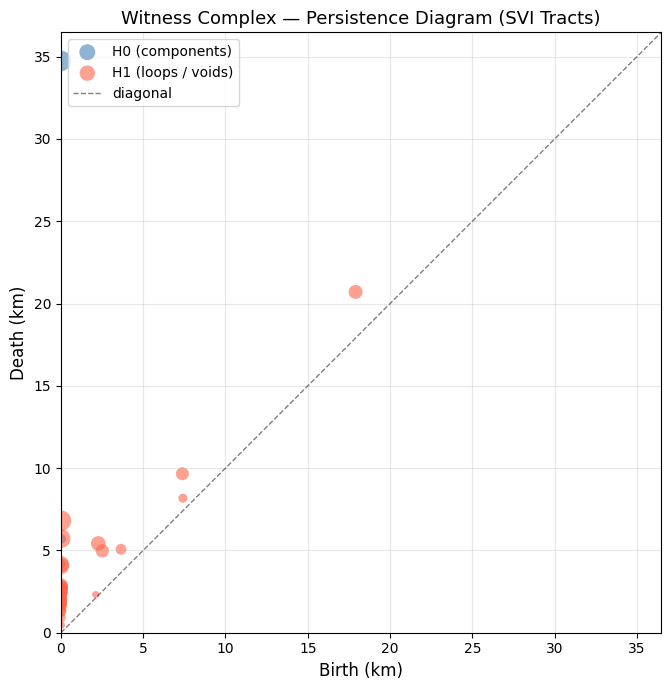

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))

plot_data = [
    (H0, "steelblue", "H0 (components)"),
    (H1, "tomato",    "H1 (loops / voids)"),
    (H2, "seagreen",  "H2 (cavities)"),
]

max_val = 0
for pairs, color, label in plot_data:
    if pairs:
        # Witness complex stores squared distances (m²); take sqrt → metres → km
        arr  = np.sqrt(np.array(pairs)) / 1000
        b, d = arr[:, 0], arr[:, 1]
        pers  = d - b
        sizes = 20 + 200 * (pers / pers.max()) if pers.max() > 0 else np.full(len(pers), 20)
        ax.scatter(b, d, s=sizes, c=color, alpha=0.6, edgecolors="none", label=label)
        max_val = max(max_val, d.max())

lim = max_val * 1.05 if max_val > 0 else 1
ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.5, label="diagonal")

# thresh_km = H1_SIG_THRESHOLD_M / 1000
# ax.axline((0, thresh_km), slope=1, color="tomato", lw=1, ls=":",
#           label=f"H1 threshold ({thresh_km:.0f} km persistence)")

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Birth (km)", fontsize=12)
ax.set_ylabel("Death (km)", fontsize=12)
ax.set_title("Witness Complex — Persistence Diagram (SVI Tracts)", fontsize=13)
ax.legend(fontsize=10)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# sig_h1 = [(b, d, d - b) for b, d in H1
#           if (np.sqrt(d) - np.sqrt(b)) >= H1_SIG_THRESHOLD_M]
# sig_h1.sort(key=lambda x: -(np.sqrt(x[1]) - np.sqrt(x[0])))
# print(f"Significant H1 voids (persistence >= {thresh_km:.0f} km): {len(sig_h1)}")
# if sig_h1:
#     print(f"{'Rank':>4}  {'Birth (km)':>10}  {'Death (km)':>10}  {'Persistence (km)':>16}")
#     print("-" * 50)
#     for rank, (b, d, _) in enumerate(sig_h1, 1):
#         bk = np.sqrt(b) / 1000
#         dk = np.sqrt(d) / 1000
#         print(f"{rank:>4}  {bk:>10.2f}  {dk:>10.2f}  {dk - bk:>16.2f}")
